# Adult Income Classification — ML Pipeline

**BITS WILP — Machine Learning Assignment 2**

This notebook is the primary experiment workflow:

1. Load & clean the UCI Adult Income dataset
2. Exploratory Data Analysis (EDA)
3. Train / test split
4. Scaling + One-Hot encoding
5. Train 5 classifiers
6. Evaluate metrics (Accuracy, AUC, Precision, Recall, F1, MCC)
7. Export models, scaler, encoder, and `test_data.csv` for the Streamlit app (`app.py`)


## 1. Imports and configuration


In [1]:
import json
from io import StringIO
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
TEST_SIZE = 0.2
ROOT = Path(".").resolve()
MODEL_DIR = ROOT / "model"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

COLUMN_NAMES = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income",
]
NUMERIC_FEATURES = [
    "age", "fnlwgt", "education_num", "capital_gain", "capital_loss", "hours_per_week",
]
CATEGORICAL_FEATURES = [
    "workclass", "education", "marital_status", "occupation",
    "relationship", "race", "sex", "native_country",
]

print("Project root:", ROOT)
print("Model dir:", MODEL_DIR)


Project root: /content
Model dir: /content/model


## 2. Load dataset (UCI Adult Income)


In [2]:
def read_adult_csv(source):
    return pd.read_csv(
        source, header=None, names=COLUMN_NAMES,
        skipinitialspace=True, na_values="?",
    )

def download_bytes(url: str) -> bytes:
    import ssl
    import urllib.request
    try:
        with urllib.request.urlopen(url, timeout=60) as resp:
            return resp.read()
    except Exception:
        ctx = ssl._create_unverified_context()
        with urllib.request.urlopen(url, timeout=60, context=ctx) as resp:
            return resp.read()

local_train = ROOT / "adult.data"
if local_train.exists():
    print(f"Loading local file: {local_train}")
    raw = read_adult_csv(local_train)
else:
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
    print(f"Downloading from UCI: {url}")
    raw = read_adult_csv(StringIO(download_bytes(url).decode("utf-8", errors="replace")))

print("Raw shape:", raw.shape)
raw.head()


Raw shape: (32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 3. Clean data


In [3]:
df = raw.copy()
for col in df.select_dtypes(include=["object", "string"]).columns:
    df[col] = df[col].astype(str).str.strip().replace({"?": np.nan, "nan": np.nan})

df["income"] = df["income"].str.replace(".", "", regex=False).str.strip()
df = df.dropna().reset_index(drop=True)

print("Cleaned shape:", df.shape)
print("Features:", df.shape[1] - 1, "| Instances:", df.shape[0])
print("Missing values after clean:", int(df.isna().sum().sum()))
df.head()


Cleaned shape: (30162, 15)
Features: 14 | Instances: 30162
Missing values after clean: 0


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 4. Exploratory Data Analysis (EDA)


Class distribution:
income
<=50K    22654
>50K      7508
Name: count, dtype: int64
income
<=50K    0.7511
>50K     0.2489
Name: proportion, dtype: float64


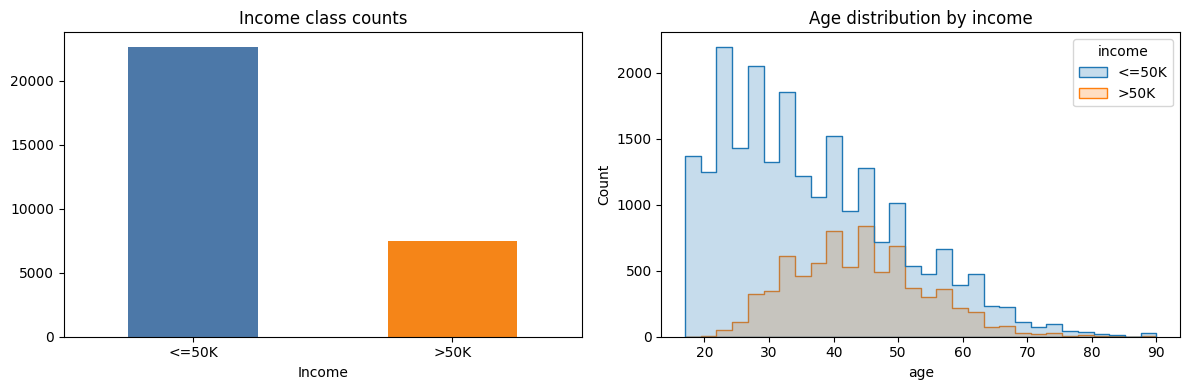

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,30162.00,30162.00,30162.00,30162.00,30162.00,30162.00
mean,38.44,189793.83,10.12,1092.01,88.37,40.93
std,13.13,105652.97,2.55,7406.35,404.30,11.98
min,17.00,13769.00,1.00,0.00,0.00,1.00
25%,28.00,117627.25,9.00,0.00,0.00,40.00
50%,37.00,178425.00,10.00,0.00,0.00,40.00
75%,47.00,237628.50,13.00,0.00,0.00,45.00
max,90.00,1484705.00,16.00,99999.00,4356.00,99.00


In [4]:
print("Class distribution:")
print(df["income"].value_counts())
print(df["income"].value_counts(normalize=True).round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["income"].value_counts().plot(kind="bar", ax=axes[0], color=["#4C78A8", "#F58518"])
axes[0].set_title("Income class counts")
axes[0].set_xlabel("Income")
axes[0].tick_params(axis="x", rotation=0)

sns.histplot(data=df, x="age", hue="income", bins=30, ax=axes[1], element="step", common_norm=False)
axes[1].set_title("Age distribution by income")
plt.tight_layout()
plt.show()

df[NUMERIC_FEATURES].describe().round(2)


## 5. Train / test split


In [5]:
X = df.drop(columns=["income"])
y_raw = df["income"]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print("Train size:", X_train.shape, "| Test size:", X_test.shape)
print("Label classes:", list(label_encoder.classes_))
print("Train class balance:", np.bincount(y_train) / len(y_train))
print("Test class balance:", np.bincount(y_test) / len(y_test))

test_export = X_test.copy()
test_export["income"] = label_encoder.inverse_transform(y_test)
test_path = ROOT / "test_data.csv"
test_export.to_csv(test_path, index=False)
print(f"Saved test_data.csv -> {test_path} ({len(test_export)} rows)")


Train size: (24129, 14) | Test size: (6033, 14)
Label classes: ['<=50K', '>50K']
Train class balance: [0.7510879 0.2489121]
Test class balance: [0.75103597 0.24896403]
Saved test_data.csv -> /content/test_data.csv (6033 rows)


## 6. Scaling + One-Hot encoding (fit on train only)


In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_FEATURES),
    ],
    remainder="drop",
)

X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)

print("Transformed train shape:", X_train_t.shape)
print("Transformed test shape:", X_test_t.shape)

scaler = preprocessor.named_transformers_["num"]
encoder = preprocessor.named_transformers_["cat"]
joblib.dump(scaler, MODEL_DIR / "scaler.pkl", compress=3)
joblib.dump(encoder, MODEL_DIR / "encoder.pkl", compress=3)
joblib.dump(preprocessor, MODEL_DIR / "preprocessor.pkl", compress=3)
joblib.dump(label_encoder, MODEL_DIR / "label_encoder.pkl", compress=3)
print("Saved scaler.pkl, encoder.pkl, preprocessor.pkl, label_encoder.pkl")


Transformed train shape: (24129, 104)
Transformed test shape: (6033, 104)
Saved scaler.pkl, encoder.pkl, preprocessor.pkl, label_encoder.pkl


## 7. Train models, evaluate metrics, save `.pkl` files


In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "kNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=20, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=-1,
    ),
}

model_file_map = {
    "Logistic Regression": "logistic_regression.pkl",
    "Decision Tree": "decision_tree.pkl",
    "kNN": "knn.pkl",
    "Naive Bayes": "naive_bayes.pkl",
    "Random Forest": "random_forest.pkl",
}

def evaluate_model(y_true, y_pred, y_proba):
    return {
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "AUC": float(roc_auc_score(y_true, y_proba)),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "F1": float(f1_score(y_true, y_pred, zero_division=0)),
        "MCC": float(matthews_corrcoef(y_true, y_pred)),
    }

metrics_rows = []
confusion_mats = {}

for name, model in models.items():
    print(f"\n=== Training {name} ===")
    model.fit(X_train_t, y_train)
    y_pred = model.predict(X_test_t)
    y_proba = model.predict_proba(X_test_t)[:, 1]
    metrics = evaluate_model(y_test, y_pred, y_proba)
    metrics["ML Model Name"] = name
    metrics_rows.append(metrics)
    confusion_mats[name] = confusion_matrix(y_test, y_pred)

    out_path = MODEL_DIR / model_file_map[name]
    joblib.dump(model, out_path, compress=3)
    print("Saved:", out_path.name)
    print({k: round(v, 4) if isinstance(v, float) else v for k, v in metrics.items()})
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))



=== Training Logistic Regression ===
Saved: logistic_regression.pkl
{'Accuracy': 0.8475, 'AUC': 0.9022, 'Precision': 0.7354, 'Recall': 0.6052, 'F1': 0.664, 'MCC': 0.5711, 'ML Model Name': 'Logistic Regression'}
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      4531
        >50K       0.74      0.61      0.66      1502

    accuracy                           0.85      6033
   macro avg       0.81      0.77      0.78      6033
weighted avg       0.84      0.85      0.84      6033


=== Training Decision Tree ===
Saved: decision_tree.pkl
{'Accuracy': 0.8087, 'AUC': 0.7478, 'Precision': 0.6134, 'Recall': 0.6265, 'F1': 0.6199, 'MCC': 0.4922, 'ML Model Name': 'Decision Tree'}
              precision    recall  f1-score   support

       <=50K       0.88      0.87      0.87      4531
        >50K       0.61      0.63      0.62      1502

    accuracy                           0.81      6033
   macro avg       0.74      0.75      0.75     

## 8. Metrics comparison table


In [8]:
metrics_df = pd.DataFrame(metrics_rows)[
    ["ML Model Name", "Accuracy", "AUC", "Precision", "Recall", "F1", "MCC"]
].sort_values("F1", ascending=False).reset_index(drop=True)

display(metrics_df.style.format({
    "Accuracy": "{:.4f}", "AUC": "{:.4f}", "Precision": "{:.4f}",
    "Recall": "{:.4f}", "F1": "{:.4f}", "MCC": "{:.4f}",
}))

winner = metrics_df.iloc[0]["ML Model Name"]
print("Overall winner (by F1):", winner)


,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Random Forest,0.8591,0.9158,0.7806,0.6039,0.6809,0.6004
1,Logistic Regression,0.8475,0.9022,0.7354,0.6052,0.6640,0.5711
2,kNN,0.8270,0.8595,0.6664,0.6105,0.6372,0.5248
3,Decision Tree,0.8087,0.7478,0.6134,0.6265,0.6199,0.4922
4,Naive Bayes,0.5826,0.8018,0.3678,0.9414,0.5290,0.3643


Overall winner (by F1): Random Forest


## 9. Confusion matrices


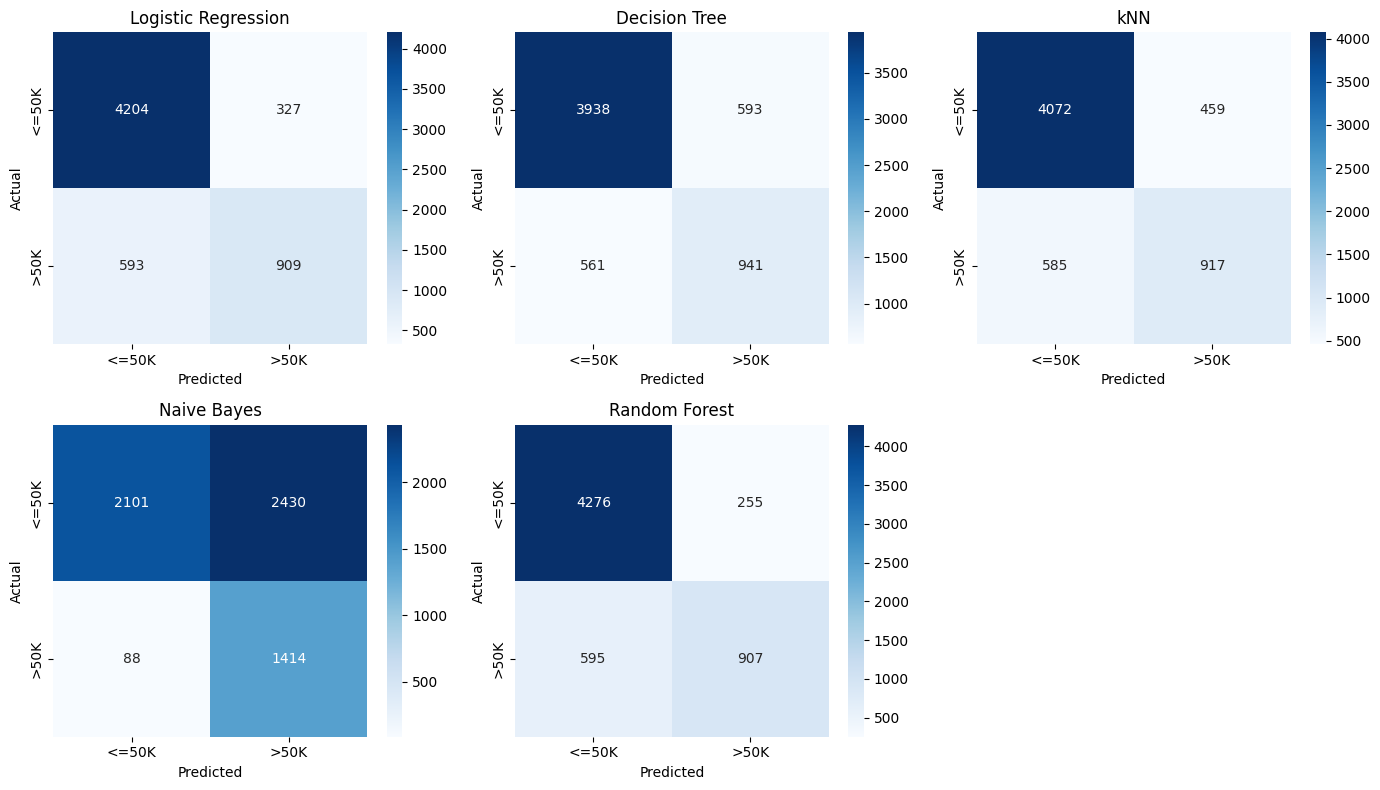

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for i, (name, cm) in enumerate(confusion_mats.items()):
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_,
    )
    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
axes[-1].axis("off")
plt.tight_layout()
plt.show()


## 10. Save metrics.json and list exported artifacts


In [10]:
payload = {
    "eda": {
        "n_rows": int(df.shape[0]),
        "n_features": int(df.shape[1] - 1),
        "class_counts": df["income"].value_counts().to_dict(),
        "class_pct": {k: float(v) for k, v in df["income"].value_counts(normalize=True).items()},
    },
    "metrics": metrics_df.to_dict(orient="records"),
    "winner": winner,
    "label_classes": list(label_encoder.classes_),
    "test_rows": int(len(X_test)),
    "train_rows": int(len(X_train)),
}

metrics_path = ROOT / "metrics.json"
metrics_path.write_text(json.dumps(payload, indent=2))
print("Saved:", metrics_path)
print("\nArtifacts in model/:")
for p in sorted(MODEL_DIR.glob("*.pkl")):
    print(f"  {p.name:30s} {p.stat().st_size / 1024:8.1f} KB")
print("\nDone. Next: streamlit run app.py")


Saved: /content/metrics.json

Artifacts in model/:
  decision_tree.pkl                  90.2 KB
  encoder.pkl                         1.5 KB
  knn.pkl                          1046.1 KB
  label_encoder.pkl                   0.3 KB
  logistic_regression.pkl             1.4 KB
  naive_bayes.pkl                     3.1 KB
  preprocessor.pkl                    2.3 KB
  random_forest.pkl                3649.2 KB
  scaler.pkl                          0.7 KB

Done. Next: streamlit run app.py
